<a href="https://colab.research.google.com/github/Aaryan8597/AI-ML-AaryanLamichhane2408597-/blob/main/Worksheet6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Verifying the Directory Structure

In [36]:
import os
#giving the path of the dataset
train_dir = "/content/drive/MyDrive/AIML/Data/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AIML/Data/FruitinAmazon/test"
#getting the sub directories inside this file
class_names = sorted(os.listdir(train_dir))
if not class_names:
  print("No class Directories found inside the train folder")
else:
  print(f"Found {len(class_names)} classes : {class_names}")

Found 6 classes : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


# Checking for Corrupted Images

In [37]:
from PIL import Image, UnidentifiedImageError
corrupted_image = []
#for loop to loop throught each folder and check for all the corrupted images
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path): #making sure that this directory is valid
    images = os.listdir(class_path)
    for img_name in images:
      img_path = os.path.join(class_path, img_name)
      try:
        with Image.open(img_path) as img:
          img.verify()
      except (IOError, UnidentifiedImageError):
        corrupted_image.append(img_path)
if corrupted_image:
  print("\n FOund Corrupted Images")
  for img in corrupted_image:
    print(img)
else:
  print("\n No Corrupted Images Found")


 No Corrupted Images Found


# Checking the Class Imbalance

In [38]:
class_count = {}
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith((".png", ".jpg", ".jpeg"))]
    class_count[class_name] = len(images) # counting images in each class
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25} {'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_count.items():
  print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name                Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


# Random Image Selection

In [39]:
import random
selected_images = [] # this stores the images path
selected_labels = [] # this stores the corresponding class names
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if images:
      selected_img = os.path.join(class_path, random.choice(images))
      selected_images.append(selected_img)
      selected_labels.append(class_name)

## Random Image Plot

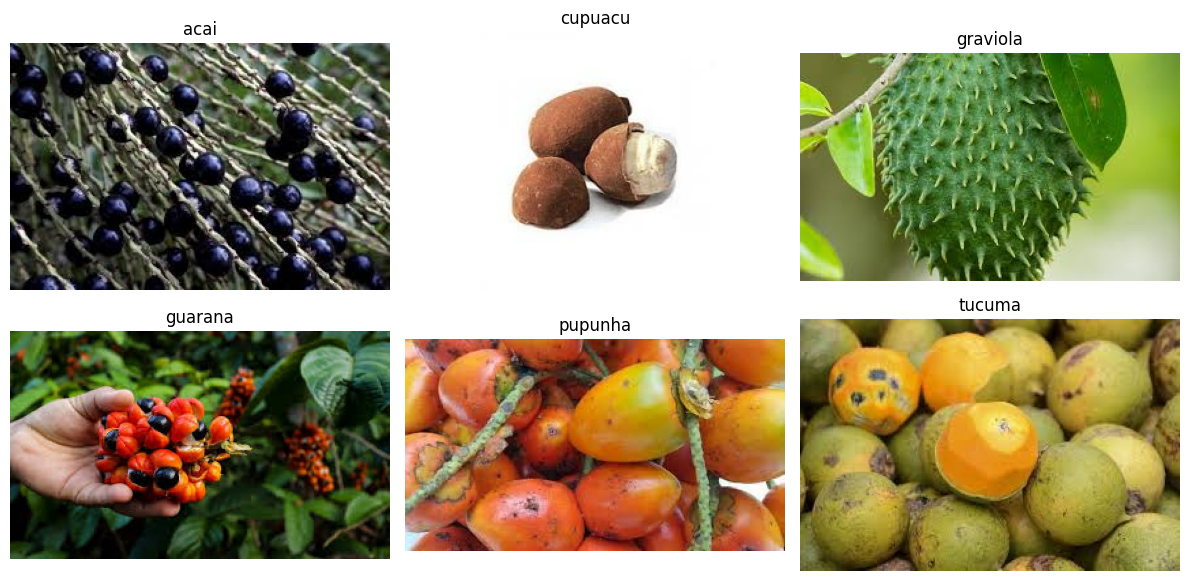

In [40]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
#determing the grid size
num_classes = len(selected_images)
#determining the column
cols = (num_classes + 1) // 2
rows = 2
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
  if i < num_classes:
    img = mpimg.imread(selected_images[i])
    ax.imshow(img)
    ax.set_title(selected_labels[i])
    ax.axis("off")
  else:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Generating the Train and Val Dataset

In [41]:
import keras
image_size = (28,28)
batch_size = 32
train_ds, val_ds = keras.utils.image_dataset_from_directory(train_dir, validation_split = 0.2, subset = "both", seed = 1337, image_size = image_size, batch_size = batch_size)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


# Data Augmentation (OLD API)

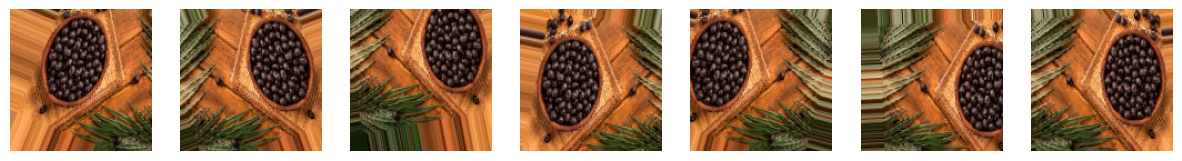

In [42]:
from IPython.core.pylabtools import figsize
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt # Import matplotlib.pyplot

datagen = ImageDataGenerator(rotation_range = 30, width_shift_range = 0.2, height_shift_range = 0.2, shear_range = 0.2,
                             horizontal_flip = True, fill_mode = 'nearest')
img = image.load_img('/content/drive/MyDrive/AIML/Data/FruitinAmazon/train/acai/images (1).jpeg', target_size = (128,128))
x = image.img_to_array(img) # this converts to numpy array
x = np.expand_dims(x, axis = 0)
#generating augmented image
aug_iter = datagen.flow(x, batch_size = 1)
# visualizing 7 augmented images now
fig, ax = plt.subplots(1, 7, figsize = (15,5)) # Changed plt.subplot to plt.subplots
for i in range(7):
  batch = next(aug_iter)
  ax[i].imshow(batch[0].astype('uint8'))
  ax[i].axis('off')
plt.show()

# Data Augmentation (New API)

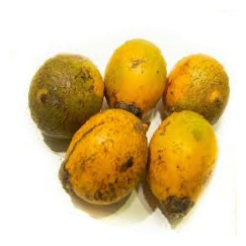

In [51]:
from tensorflow.keras import layers
data_augmentation_layers = [layers.RandomFlip("horizontal"), layers.RandomRotation(0.1)]
def data_augmentation(images):
  for layer in data_augmentation_layers:
    images = layer(images)
  return images

model = keras.Sequential([layers.Input(shape = (128,128,3)),
                          *data_augmentation_layers, layers.Conv2D(32,(3,3), activation = "relu"), layers.MaxPooling2D(),
                          layers.Flatten(), layers.Dense(10, activation = "softmax")])
plt.figure(figsize = (10,10))
for images, _ in train_ds.take(1):
  augmented_images = data_augmentation(images)
  ax = plt.subplot(3,3, i + 1)
  plt.imshow(np.array(augmented_images[0]).astype('uint8'))
  plt.axis('off')

# Task-1

In [45]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization, Activation
#setting image  size and batch size
img_height = 224
img_width = 224
batch_size = 32
#splitting data into 80% training and 20% validation
validation_split = 0.2

#training the dataset with normalizaiton
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, labels = 'inferred', label_mode = 'int', image_size = (img_height, img_width),
    interpolation = 'nearest', batch_size = batch_size, shuffle = True, validation_split = validation_split,
    subset = 'training', seed = 123)
# loading the validation images from same folder
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, labels = 'inferred', label_mode = 'int', image_size = (img_height, img_width),
    interpolation = 'nearest', batch_size = batch_size, shuffle = True, validation_split = validation_split,
    subset = 'validation', seed = 123)

data_augmentation_layers = [layers.RandomFlip("horizontal"), layers.RandomRotation(0.1)]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

# improving the model architecture
model = Sequential([
    layers.Lambda(data_augmentation, input_shape=(224, 224, 3)),
    layers.Rescaling(1./255),

    # Conv Blocks 1 to 4
    Conv2D(32, (3, 3), padding='same'),
    BatchNormalization(), Activation('relu'),
    MaxPooling2D((2, 2)), Dropout(0.25),

    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(), Activation('relu'),
    MaxPooling2D((2, 2)), Dropout(0.25),

    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(), Activation('relu'),
    MaxPooling2D((2, 2)), Dropout(0.25),

    Conv2D(256, (3, 3), padding='same'),
    BatchNormalization(), Activation('relu'),
    MaxPooling2D((2, 2)), Dropout(0.25),

    # Flattening the output of last con2D layer
    Flatten(),

    # 512 Layer
    Dense(512),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # 256 Layer
    Dense(256),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # 128 layer
    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # 64 Layer
    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Output Layer that hass 10 neurons
    Dense(10, activation='softmax')
])
model.compile( optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 50176)          │             

 Total params: 26,257,930 (100.17 MB)

 Trainable params: 26,255,050 (100.16 MB)

 Non-trainable params: 2,880 (11.25 KB)

In [46]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_loss',
    save_best_only=True
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
# Training for up to 300 epochs
history = model.fit(train_ds, validation_data=val_ds, epochs=300, callbacks=[checkpoint, early_stop])


Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.0394 - loss: 3.2007

3/3 ━━━━━━━━━━━━━━━━━━━━ 30s 6s/step - accuracy: 0.0556 - loss: 3.2112 - val_accuracy: 0.0556 - val_loss: 2.3461
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 40s 5s/step - accuracy: 0.1111 - loss: 2.9061 - val_accuracy: 0.0000e+00 - val_loss: 2.3638
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.1528 - loss: 2.9489 - val_accuracy: 0.0000e+00 - val_loss: 2.4182
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 6s/step - accuracy: 0.1389 - loss: 2.4633 - val_accuracy: 0.0000e+00 - val_loss: 2.4234
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.1667 - loss: 2.8305 - val_accuracy: 0.0000e+00 - val_loss: 2.4136
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 6s/step - accuracy: 0.2083 - loss: 2.6989 - val_accuracy: 0.0000e+00 - val_loss: 2.3894
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step - accuracy: 0.2639 - loss: 2.3823 - val_accuracy: 0.0000e+00 - val_loss: 2.3633
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2442 - loss: 2.2229

3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 6s/step - accuracy: 0.2639 - loss: 2.2636 - val_accuracy: 0.1667 - val_loss: 2.3389
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2610 - loss: 2.3087

3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - accuracy: 0.2361 - loss: 2.3840 - val_accuracy: 0.1667 - val_loss: 2.3089
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2251 - loss: 2.1672

3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 6s/step - accuracy: 0.2222 - loss: 2.2086 - val_accuracy: 0.1667 - val_loss: 2.2798
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3206 - loss: 2.0308

3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 6s/step - accuracy: 0.3056 - loss: 2.0929 - val_accuracy: 0.1667 - val_loss: 2.2545
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2801 - loss: 2.0201

3/3 ━━━━━━━━━━━━━━━━━━━━ 29s 6s/step - accuracy: 0.2778 - loss: 2.0339 - val_accuracy: 0.1667 - val_loss: 2.2406
Epoch 13/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2639 - loss: 2.0992

3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 7s/step - accuracy: 0.2917 - loss: 2.0492 - val_accuracy: 0.1667 - val_loss: 2.2324
Epoch 14/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2500 - loss: 1.9475

3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - accuracy: 0.2500 - loss: 2.0004 - val_accuracy: 0.1667 - val_loss: 2.2238
Epoch 15/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2737 - loss: 2.0237

3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step - accuracy: 0.3056 - loss: 2.0070 - val_accuracy: 0.1667 - val_loss: 2.2211
Epoch 16/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step - accuracy: 0.3611 - loss: 1.9975 - val_accuracy: 0.1667 - val_loss: 2.2303
Epoch 17/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - accuracy: 0.3611 - loss: 1.9119 - val_accuracy: 0.1667 - val_loss: 2.2411
Epoch 18/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step - accuracy: 0.4306 - loss: 1.6838 - val_accuracy: 0.1667 - val_loss: 2.2434
Epoch 19/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.3611 - loss: 1.7598 - val_accuracy: 0.1667 - val_loss: 2.2449
Epoch 20/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.3750 - loss: 2.0629 - val_accuracy: 0.1667 - val_loss: 2.2422
Epoch 21/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.3472 - loss: 1.7998 - val_accuracy: 0.1667 - val_loss: 2.2309
Epoch 22/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step - accuracy: 0.3889 - loss: 1.7756 - val_accuracy: 0.1667 - val_loss: 2.2325
Epoch

# Image classification through Fine-tuning

In [48]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Loading VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
#freezing the layer
for layer in base_model.layers:
    layer.trainable = False
#adding the custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(10, activation='softmax')(x)
#creating the final model
model_vgg = Model(inputs=base_model.input, outputs=predictions)
#compiling and fitting the model
model_vgg.compile(optimizer=Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
checkpoint_vgg = ModelCheckpoint(
    "best_vgg_model.h5",
    monitor='val_loss',
    save_best_only=True
)
history_vgg = model_vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint_vgg, early_stop])


Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.1632 - loss: 7.1040 

3/3 ━━━━━━━━━━━━━━━━━━━━ 67s 24s/step - accuracy: 0.2083 - loss: 7.0800 - val_accuracy: 0.4444 - val_loss: 7.4383
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.5081 - loss: 4.7006 

3/3 ━━━━━━━━━━━━━━━━━━━━ 53s 17s/step - accuracy: 0.5556 - loss: 3.9988 - val_accuracy: 0.4444 - val_loss: 3.7409
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 89s 21s/step - accuracy: 0.8889 - loss: 0.6357 - val_accuracy: 0.2778 - val_loss: 7.8097
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 60s 21s/step - accuracy: 0.8333 - loss: 0.9755 - val_accuracy: 0.3889 - val_loss: 4.7563
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 60s 21s/step - accuracy: 0.9722 - loss: 0.0573 - val_accuracy: 0.4444 - val_loss: 4.0060
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 75s 17s/step - accuracy: 0.9861 - loss: 0.0305 - val_accuracy: 0.5000 - val_loss: 4.3225
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 89s 21s/step - accuracy: 0.9722 - loss: 0.0930 - val_accuracy: 0.5000 - val_loss: 4.6023
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 60s 21s/step - accuracy: 1.0000 - loss: 0.0126 - val_accuracy: 0.5556 - val_loss: 4.6758
Epoch 9/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 51s 16s/step - accuracy: 1.0000 - loss: 5.3494e-04 - val_accuracy: 0.5556 - val_loss: 5.0880
Epoch 1

In [50]:
import numpy as np
from sklearn.metrics import classification_report
test_ds_vgg = test_ds.map(lambda x, y: (tf.cast(x, tf.float32), y))

test_loss, test_acc = model_vgg.evaluate(test_ds_vgg, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}\n")
predictions = model_vgg.predict(test_ds_vgg, verbose=0)
y_pred = np.argmax(predictions, axis=1)
y_true = np.concatenate([y for x, y in test_ds_vgg], axis=0)
target_names = [train_ds.class_names[i] for i in np.unique(y_true)]

print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

Test Accuracy: 0.3667

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.30      0.60      0.40         5
    graviola       1.00      0.20      0.33         5
     guarana       1.00      0.40      0.57         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.29      1.00      0.45         5

    accuracy                           0.37        30
   macro avg       0.43      0.37      0.29        30
weighted avg       0.43      0.37      0.29        30

